In [22]:
## Transfer learning

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import torchvision
import numpy as np

In [21]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(torch.cuda.get_device_name(0)) no GPU available here
# device

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)  # should say mps

mps


In [23]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

])
## load entire datasets

dataset = datasets.ImageFolder(root="./images", transform=transform)

In [24]:
len(dataset)

9144

In [5]:
dataset.classes

['BACKGROUND_Google',
 'Faces',
 'Faces_easy',
 'Leopards',
 'Motorbikes',
 'accordion',
 'airplanes',
 'anchor',
 'ant',
 'barrel',
 'bass',
 'beaver',
 'binocular',
 'bonsai',
 'brain',
 'brontosaurus',
 'buddha',
 'butterfly',
 'camera',
 'cannon',
 'car_side',
 'ceiling_fan',
 'cellphone',
 'chair',
 'chandelier',
 'cougar_body',
 'cougar_face',
 'crab',
 'crayfish',
 'crocodile',
 'crocodile_head',
 'cup',
 'dalmatian',
 'dollar_bill',
 'dolphin',
 'dragonfly',
 'electric_guitar',
 'elephant',
 'emu',
 'euphonium',
 'ewer',
 'ferry',
 'flamingo',
 'flamingo_head',
 'garfield',
 'gerenuk',
 'gramophone',
 'grand_piano',
 'hawksbill',
 'headphone',
 'hedgehog',
 'helicopter',
 'ibis',
 'inline_skate',
 'joshua_tree',
 'kangaroo',
 'ketch',
 'lamp',
 'laptop',
 'llama',
 'lobster',
 'lotus',
 'mandolin',
 'mayfly',
 'menorah',
 'metronome',
 'minaret',
 'nautilus',
 'octopus',
 'okapi',
 'pagoda',
 'panda',
 'pigeon',
 'pizza',
 'platypus',
 'pyramid',
 'revolver',
 'rhino',
 'rooste

In [25]:
train_size=int(0.8 * len(dataset))
test_size= len(dataset)-train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
len(train_dataset), len(test_dataset)

(7315, 1829)

In [26]:
## create data loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [27]:
for batch in enumerate(train_loader):
    print(batch)
    break

(0, [tensor([[[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          ...,
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],

         [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          ...,
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],

         [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.00

In [28]:
for i , (images, label) in enumerate(train_loader):
    print(images.shape)
    print(label.shape)
    break

torch.Size([32, 3, 128, 128])
torch.Size([32])


In [29]:
for images, labels in train_loader:
    print(labels)
    break


tensor([72, 24,  6, 95,  2, 32,  4, 52, 13, 93, 21,  1,  0, 76, 64,  3,  0,  6,
        93, 17,  6, 13,  4, 96, 25,  0,  4,  6, 97,  6,  1,  4])


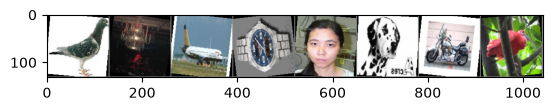

In [30]:
def imgshow(img):
    img = img/2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# show images

imgshow(torchvision.utils.make_grid(images[:8]))

In [31]:
label[:8]

tensor([24, 81, 86, 39, 37, 23,  0, 37])

In [32]:
classes = [dataset.classes[i] for i in label[:8]]
classes

['chandelier',
 'scissors',
 'stapler',
 'euphonium',
 'elephant',
 'chair',
 'BACKGROUND_Google',
 'elephant']

## Model Training Without Transfer Learning

In [33]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=(3,3), padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(stride=(2,2), kernel_size=(2,2)),

            nn.Conv2d(32, 64, kernel_size=(3,3), padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(stride=(2,2), kernel_size=(2, 2)),

            nn.Flatten(),
            nn.Linear(64*32*32, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)


        )


    def forward(self, x):
        return self.network(x)

In [34]:
def train_model(model, optimizer, criterion, train_loader, test_loader, num_epochs=2):
    for epoch in range(num_epochs):
        model.train()
        running_loss=0.0
        
        for images, labels in train_loader:
            images , labels = images.to(device), labels.to(device)


            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss:{running_loss/len(train_loader):.4f}")

In [35]:
## start model training

num_classes = len(dataset.classes)
model = CNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_model(model, optimizer, criterion, train_loader, test_loader, num_epochs=2)


Epoch [1/2], Loss:3.3680
Epoch [2/2], Loss:2.4867


In [36]:
def test_model(model, test_loader):
    model.eval()
    correct = 0 
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test accuracy : {100 * correct / total:.2f}%")


test_model(model, test_loader)

Test accuracy : 44.23%


## Model Training With Transfer Learning

In [37]:
num_classes

102

### ResNet 18

In [38]:
from torchvision import models

## loading a pre-trained model

model = models.resnet18(weights="DEFAULT")

## replace the fully connected layers

model.fc = nn.Linear(model.fc.in_features, num_classes)

model.to(device)

## define the loss function and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


train_model(model, optimizer, criterion, train_loader, test_loader, num_epochs=2)
test_model(model, test_loader)

Epoch [1/2], Loss:2.0143
Epoch [2/2], Loss:1.0683
Test accuracy : 72.28%


In [39]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_model(model, optimizer, criterion, train_loader, test_loader, num_epochs=2)   
test_model(model, test_loader) 

Epoch [1/2], Loss:1.4742
Epoch [2/2], Loss:0.5553
Test accuracy : 85.35%
